Hands-on Lab Challenge #1
[HANDS-ON LAB CHALLENGE] Lab #1: Customer Data Hygiene & Feature Separation

In [10]:
import pandas as pd

# Initial Dataset
df_lab1 = pd.DataFrame({
    'full_name': [' John Smith ', 'Jane Doe', ' peter jones '],
    'location': ['123 Main St, New York, USA', '456 Oak Ave, London, UK', '789 Pine Ln, New York, USA']
})

# Task 1: Normalize Names
df_lab1['cleaned_name'] = df_lab1['full_name'].str.strip().str.title()

# Task 2: Filter Region
ny_customers = df_lab1[df_lab1['location'].str.contains('New York')]

# Task 3: Decompose Location
df_lab1[['street', 'city', 'country']] = df_lab1['location'].str.split(', ', expand=True)

# Output results
print("--- Main DataFrame ---")
print(df_lab1)
print("\n--- New York Customers ---")
print(ny_customers)

--- Main DataFrame ---
       full_name                    location cleaned_name       street  \
0    John Smith   123 Main St, New York, USA   John Smith  123 Main St   
1       Jane Doe     456 Oak Ave, London, UK     Jane Doe  456 Oak Ave   
2   peter jones   789 Pine Ln, New York, USA  Peter Jones  789 Pine Ln   

       city country  
0  New York     USA  
1    London      UK  
2  New York     USA  

--- New York Customers ---
       full_name                    location cleaned_name
0    John Smith   123 Main St, New York, USA   John Smith
2   peter jones   789 Pine Ln, New York, USA  Peter Jones


Module 3: Working with Time Series Data


Converting Strings to Datetime Objects


In [11]:
import pandas as pd
dates = pd.Series(pd.to_datetime([
'2023-01-01', '2023-02-15', '2023-03-30'
]))
# Extract temporal components using .dt
df_feats = pd.DataFrame({
'date': dates,
'year': dates.dt.year,
'month': dates.dt.month,
'day_name': dates.dt.day_name(),
'dayofweek': dates.dt.dayofweek, # Mon=0
'quarter': dates.dt.quarter
})

Setting a DatetimeIndex

In [13]:
import pandas as pd
df = pd.DataFrame({
'sale_date': ['2023-01-15', '2023-01-16'],
'sales': [100, 150]
})
# 1. Convert column to datetime
df['sale_date'] = pd.to_datetime(df['sale_date'])
# 2. Set as primary DataFrame Index
df.set_index('sale_date', inplace=True)
print(df.info())
print("\nIndex Type:", type(df.index))

<class 'pandas.DataFrame'>
DatetimeIndex: 2 entries, 2023-01-15 to 2023-01-16
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   sales   2 non-null      int64
dtypes: int64(1)
memory usage: 32.0 bytes
None

Index Type: <class 'pandas.DatetimeIndex'>


Intelligent Time Series Selection & Slicing


In [14]:
import numpy as np
import pandas as pd
dates = pd.date_range('2020-01-01', periods=1000)
ts = pd.Series(np.random.randn(1000), index=dates)
# 1. Select entire year
ts_2021 = ts.loc['2021']
# 2. Select specific month
ts_may_2021 = ts.loc['2021-05']
# 3. Slice closed date range (inclusive!)
ts_jan_2022 = ts.loc['2022-01-01':'2022-01-31']
print(ts_jan_2022.head(3))

2022-01-01   -0.188397
2022-01-02    0.441714
2022-01-03    1.241925
Freq: D, dtype: float64


Temporal Feature Engineering with .dt


In [16]:
import pandas as pd
dates = pd.Series(pd.to_datetime([
'2023-01-01', '2023-02-15', '2023-03-30'
]))
# Extract temporal components using .dt
df_feats = pd.DataFrame({
'date': dates,
'year': dates.dt.year,
'month': dates.dt.month,
'day_name': dates.dt.day_name(),
'dayofweek': dates.dt.dayofweek, # Mon=0
'quarter': dates.dt.quarter
})

LAB 3

Tổng doanh thu tháng 02/2023: $10043

Trung bình doanh thu theo ngày:
 day_name
Monday       308
Tuesday      284
Wednesday    298
Thursday     288
Friday       394
Saturday     494
Sunday       484
Name: sales, dtype: int64


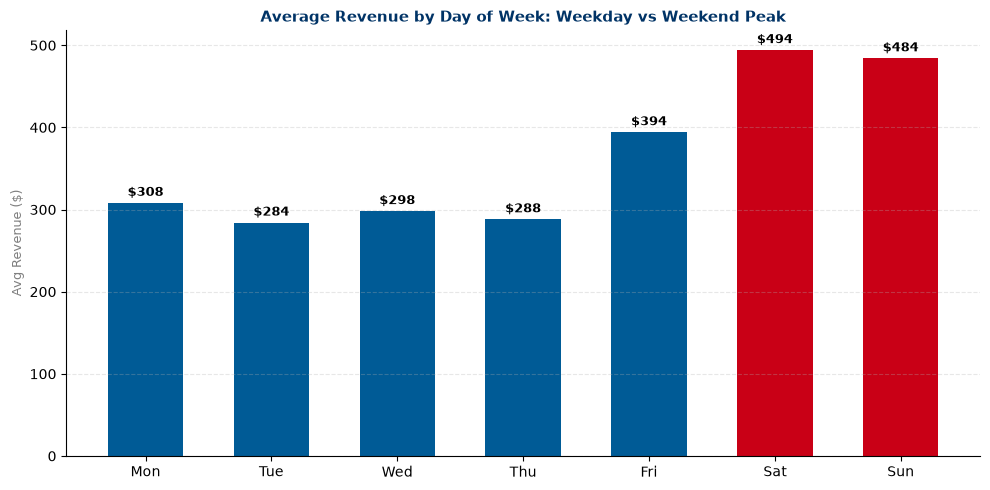

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SETUP DỮ LIỆU BAN ĐẦU (Như trong ảnh) ---
np.random.seed(2023)
dates = pd.date_range('2023-01-01', periods=90, freq='D')
wknd = np.where(dates.dayofweek >= 5, 180, 0)
fri = np.where(dates.dayofweek == 4, 100, 0)
noise = np.random.normal(0, 30, 90)
df_sales = pd.DataFrame({
    'date': dates.strftime('%Y-%m-%d'),
    'sales': np.clip(300 + wknd + fri + noise, 100, 700).astype(int)
})

# --- 2. GIẢI QUYẾT 4 TASKS ---

# Task 1: Chuyển đổi sang datetime và gán làm Index
df_sales['date'] = pd.to_datetime(df_sales['date'])
df_sales = df_sales.set_index('date')

# Task 2: Cắt dữ liệu tháng 2/2023 và tính tổng
feb_sales = df_sales.loc['2023-02', 'sales'].sum()
print(f"Tổng doanh thu tháng 02/2023: ${feb_sales}")

# Task 3: Trích xuất tên thứ trong tuần
# Set categorical để ép thứ tự từ T2 -> CN (quan trọng cho bước vẽ biểu đồ)
cats = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_sales['day_name'] = pd.Categorical(df_sales.index.day_name(), categories=cats, ordered=True)

# Task 4: Tính doanh thu trung bình theo thứ
avg_revenue = df_sales.groupby('day_name', observed=False)['sales'].mean().round(0).astype(int)
print("\nTrung bình doanh thu theo ngày:\n", avg_revenue)


# --- 3. VẼ BIỂU ĐỒ (Bonus để ra Expected Output) ---
plt.figure(figsize=(10, 5))

# Đặt màu: T2-T6 màu xanh, T7-CN màu đỏ
colors = ['#005b96']*5 + ['#c90016']*2 
bars = plt.bar(avg_revenue.index.str[:3], avg_revenue.values, color=colors, width=0.6)

# Gắn nhãn text lên đầu mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, f'${yval}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.title('Average Revenue by Day of Week: Weekday vs Weekend Peak', fontweight='bold', fontsize=11, color='#003366')
plt.ylabel('Avg Revenue ($)', fontsize=9, color='gray')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()